In [22]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

In [23]:
df = pd.read_csv('../dataset/cmi_internet_cleaned.csv')
X = df.drop(columns=['sii'])
y = np.array(df['sii'])

## **0. Preprocessing**

In [31]:
from sklearn.model_selection import train_test_split, cross_val_score 

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [ ]:
X_train.shape, y_train.shape            

((5487, 32), (5487,))

## 1. **Random Forest**

4 classes, imbalanced

Starting Random Forest Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}
Best Balanced Accuracy Score (CV): 0.3440

Evaluating Best Random Forest Model on Test Set...


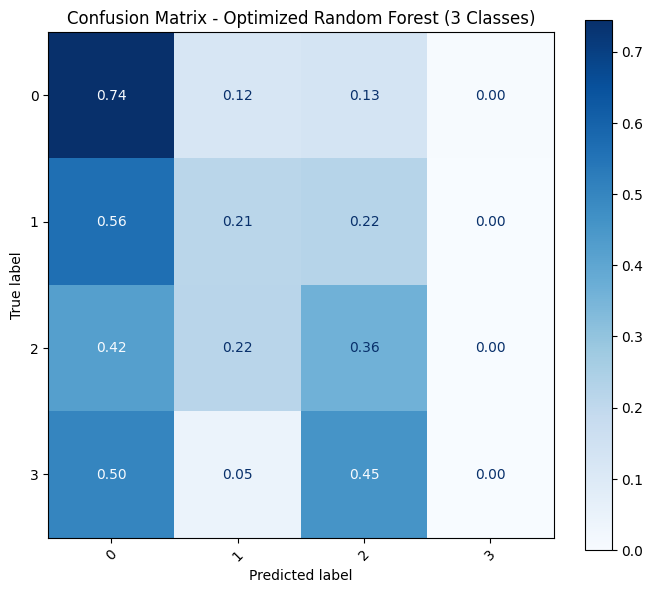

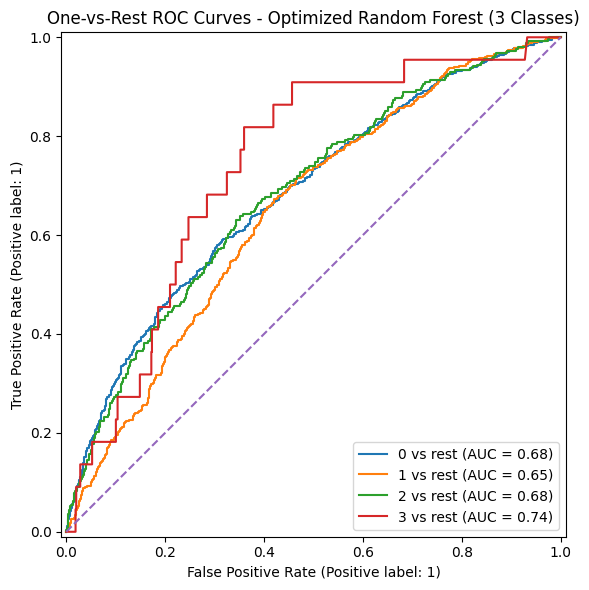

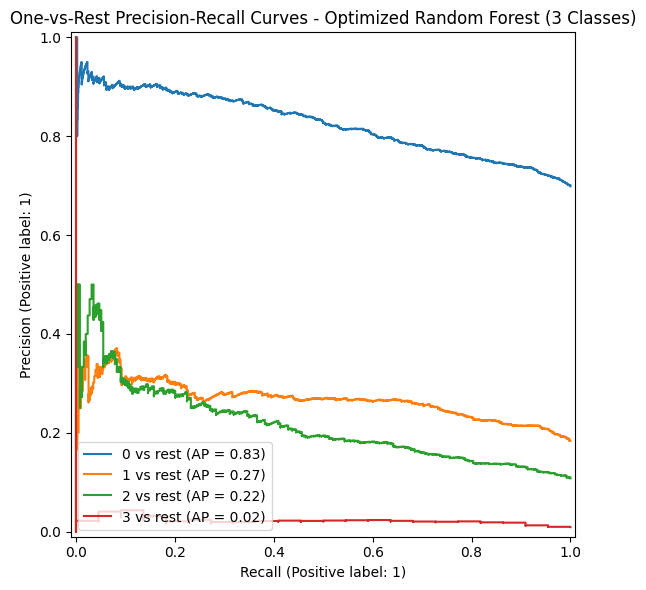


Classification report - Optimized Random Forest (3 Classes)


,precision,recall,f1-score,support
0,0.771753,0.744979,0.758129,1643.000000
1,0.269006,0.212471,0.237419,433.000000
2,0.221154,0.362205,0.274627,254.000000
3,0.000000,0.000000,0.000000,22.000000
accuracy,0.598639,0.598639,0.598639,0.598639
macro avg,0.315478,0.329914,0.317544,2352.000000
weighted avg,0.612518,0.598639,0.602961,2352.000000


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from evaluate_classifier import evaluate_classifier

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist = {
    # Numero di alberi nella foresta
    'n_estimators': [100, 200, 300, 500],
    
    # Massima profondità di ogni albero (previene l'overfitting)
    'max_depth': [None, 10, 20, 30, 40],
    
    # Numero minimo di campioni richiesti per dividere un nodo interno
    'min_samples_split': [2, 5, 10],
    
    # Numero minimo di campioni richiesti in un nodo foglia
    'min_samples_leaf': [1, 2, 4],
    
    # Numero di feature da considerare per la scelta del chunk migliore
    'max_features': ['sqrt', 'log2', None],

    # Funzione di impurità per la divisione dei nodi
    'criterion': ['gini', 'entropy'],
    
    # STRATEGIA DI BILANCIAMENTO: 'balanced_subsample' calcola i pesi 
    # sulla combinazione bootstrap di ogni singolo albero (potentissimo)
    'class_weight': ['balanced', 'balanced_subsample']
    # queste opzioni aiutano a gestire dataset sbilanciati,
    # dando più peso alle classi minoritarie
}

# Modello base
rf_base = RandomForestClassifier(random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Random Forest Hyperparameter Tuning...")

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                     # Numero di combinazioni casuali da testare
    cv=5,                          # 5-Fold Cross-Validation per massima stabilità
    scoring='balanced_accuracy',   # Ottimizziamo per la balanced accuracy
    n_jobs=-1,                     # Usa tutti i core della CPU disponibili
    random_state=42,
    verbose=1
)

# Eseguiamo il fit sui dati originali a 3 classi
random_search_rf.fit(X_train, y_train)

# Estrazione del modello migliore e dei parametri
best_rf = random_search_rf.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_rf.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_rf.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Random Forest Model on Test Set...")

# Utilizziamo la tua funzione evaluate_classifier originale passandogli direttamente il modello
results, report_df = evaluate_classifier(
    model=best_rf,
    X_test=X_test,       # Test set reale a 3 classi
    y_test=y_test,
    model_name="Optimized Random Forest (3 Classes)",
    normalize_cm="true"
)

3 class problem, imbalanced

In [10]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================================
# 0. AGGREGAZIONE CLASSI E NUOVO SPLIT (Da eseguire prima del tuo codice)
# =========================================================================

# Se nel tuo array/dataframe i tag partono da 0 (0, 1, 2, 3), la classe 3 è il valore 2 e la 4 è il valore 3.
# Con replace({3: 2}) uniamo la classe più grave alla precedente.
y_clean_3classes = df['sii'].replace({3: 2})

print("Nuova distribuzione delle 3 macro-classi:")
print(Counter(y_clean_3classes))
# Risultato atteso: {0: 5476, 1: 1444, 2: 919}

# Rigeneriamo i dataset di Train e Test stratificati sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.2, random_state=42, stratify=y_clean_3classes
)

print(f"\nData preparation completata. Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Puoi lanciare la tua RandomizedSearch della Random Forest...")

Nuova distribuzione delle 3 macro-classi:
Counter({0: 5476, 1: 1444, 2: 919})

Data preparation completata. Train size: (6271, 32), Test size: (1568, 32)
Puoi lanciare la tua RandomizedSearch della Random Forest...


Starting Random Forest Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'gini', 'class_weight': 'balanced'}
Best Balanced Accuracy Score (CV): 0.4599

Evaluating Best Random Forest Model on Test Set...


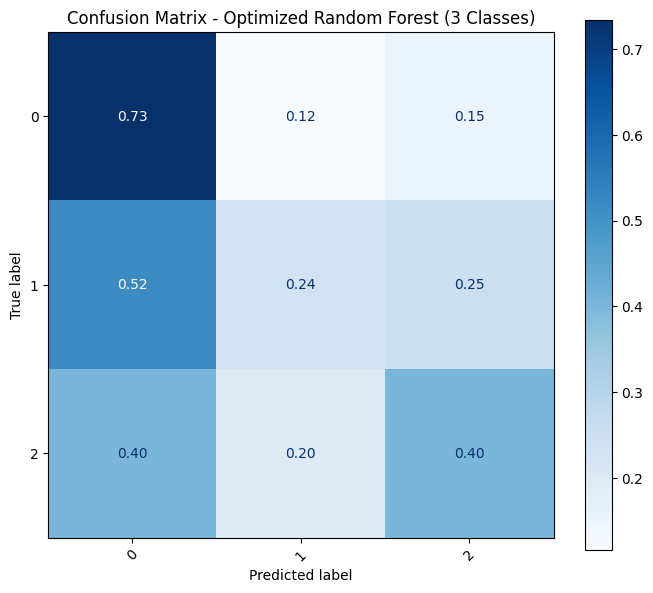

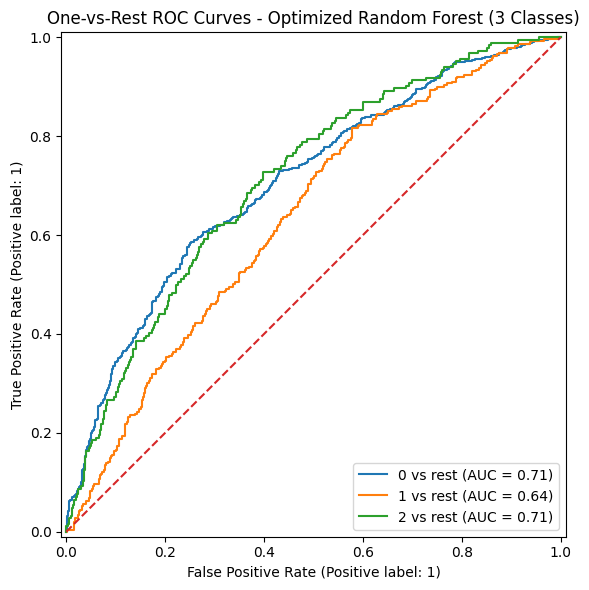

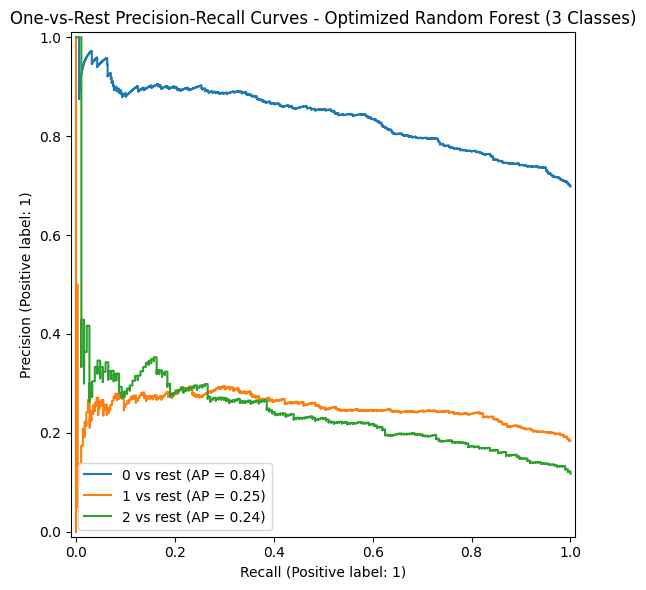


Classification report - Optimized Random Forest (3 Classes)


,precision,recall,f1-score,support
0,0.782863,0.734247,0.757776,1095.000000
1,0.294372,0.235294,0.261538,289.000000
2,0.238710,0.402174,0.299595,184.000000
accuracy,0.603316,0.603316,0.603316,0.603316
macro avg,0.438648,0.457238,0.439636,1568.000000
weighted avg,0.628974,0.603316,0.612548,1568.000000


In [11]:
# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist = {
    # Numero di alberi nella foresta
    'n_estimators': [100, 200, 300, 500],
    
    # Massima profondità di ogni albero (previene l'overfitting)
    'max_depth': [None, 10, 20, 30, 40],
    
    # Numero minimo di campioni richiesti per dividere un nodo interno
    'min_samples_split': [2, 5, 10],
    
    # Numero minimo di campioni richiesti in un nodo foglia
    'min_samples_leaf': [1, 2, 4],
    
    # Numero di feature da considerare per la scelta del chunk migliore
    'max_features': ['sqrt', 'log2', None],

    # Funzione di impurità per la divisione dei nodi
    'criterion': ['gini', 'entropy'],
    
    # STRATEGIA DI BILANCIAMENTO: 'balanced_subsample' calcola i pesi 
    # sulla combinazione bootstrap di ogni singolo albero (potentissimo)
    'class_weight': ['balanced', 'balanced_subsample']
}

# Modello base
rf_base = RandomForestClassifier(random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Random Forest Hyperparameter Tuning...")

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,                     # Numero di combinazioni casuali da testare
    cv=5,                          # 5-Fold Cross-Validation per massima stabilità
    scoring='balanced_accuracy',   # Ottimizziamo per la balanced accuracy
    n_jobs=-1,                     # Usa tutti i core della CPU disponibili
    random_state=42,
    verbose=1
)

# Eseguiamo il fit sui dati originali a 3 classi
random_search_rf.fit(X_train, y_train)

# Estrazione del modello migliore e dei parametri
best_rf = random_search_rf.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_rf.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_rf.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Random Forest Model on Test Set...")

# Utilizziamo la tua funzione evaluate_classifier originale passandogli direttamente il modello
results, report_df = evaluate_classifier(
    model=best_rf,
    X_test=X_test,       # Test set reale a 3 classi
    y_test=y_test,
    model_name="Optimized Random Forest (3 Classes)",
    normalize_cm="true"
)

3 classes, ENN (undersampling of the majority class)

Starting ENN + Random Forest Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'rf__n_estimators': 200, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 4, 'rf__max_depth': 10, 'rf__criterion': 'gini', 'rf__class_weight': 'balanced', 'enn__n_neighbors': 3, 'enn__kind_sel': 'mode'}
Best Balanced Accuracy Score (CV): 0.4702

Evaluating Best ENN + RF Model on Test Set...


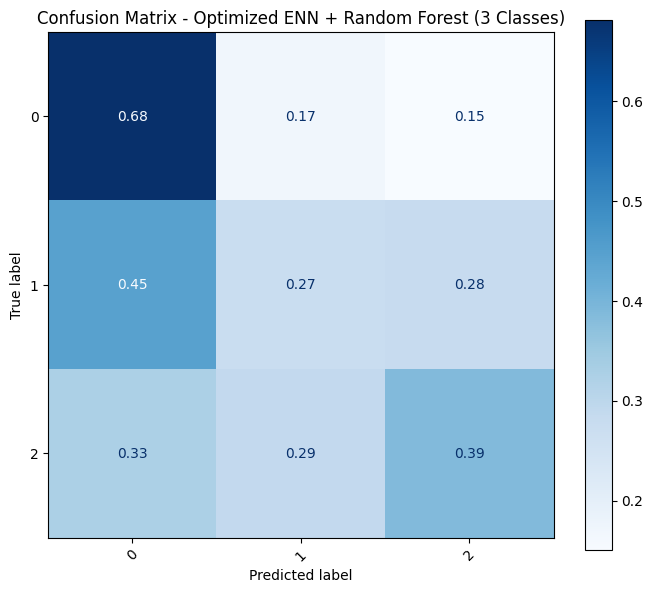

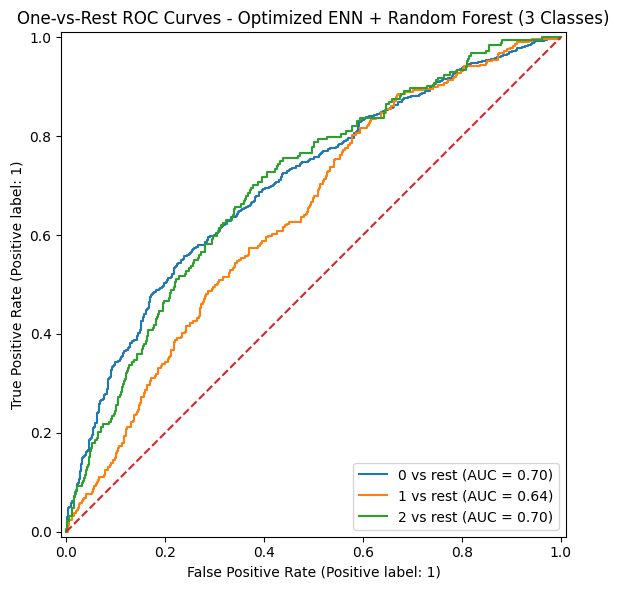

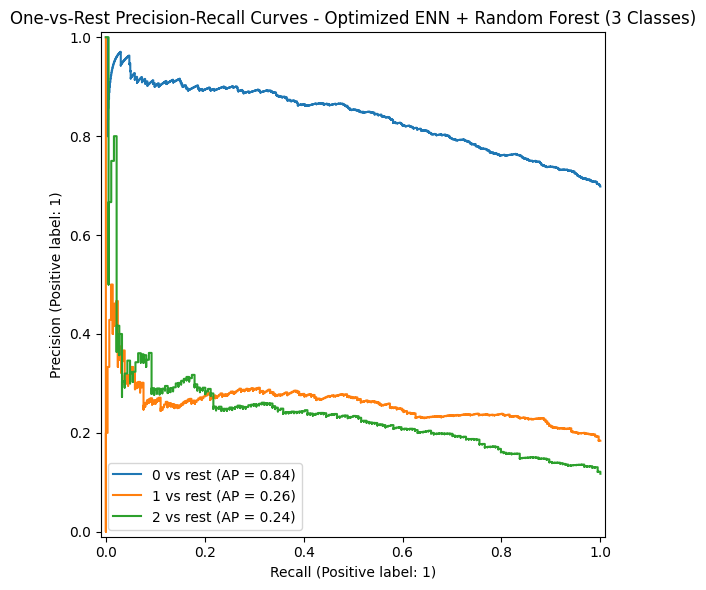


Classification report - Optimized ENN + Random Forest (3 Classes)


,precision,recall,f1-score,support
0,0.797861,0.681279,0.734975,1095.000000
1,0.250000,0.273356,0.261157,289.000000
2,0.223975,0.385870,0.283433,184.000000
accuracy,0.571429,0.571429,0.571429,0.571429
macro avg,0.423945,0.446835,0.426522,1568.000000
weighted avg,0.629540,0.571429,0.594658,1568.000000


In [16]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline as ImbPipeline

# =========================================================================
# 1. SPAZIO IPERPARAMETRI (Con prefisso 'rf__' per la Pipeline)
# =========================================================================
param_dist = {
    # Parametri dell'ENN (Proviamo diversi numeri di vicini per la pulizia)
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'], # 'all' è più aggressivo nell'eliminare i punti confusi
    
    # Parametri della Random Forest
    'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [None, 10, 20, 30, 40],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__criterion': ['gini', 'entropy'],
    'rf__class_weight': [None, 'balanced'] # Vediamo se serve combinare ENN e pesi
}

# Inizializziamo i componenti base
enn_sampler = EditedNearestNeighbours(sampling_strategy='majority') # Rimuove campioni confusi dalla classe maggioritaria
rf_base = RandomForestClassifier(random_state=42)

# Costruiamo la pipeline protetta
pipeline_rf_enn = ImbPipeline([
    ('enn', enn_sampler), # Fase 1: Pulizia dei confini della classe maggioritaria
    ('rf', rf_base)       # Fase 2: Classificazione con Random Forest
])

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting ENN + Random Forest Hyperparameter Tuning...")

random_search_enn = RandomizedSearchCV(
    estimator=pipeline_rf_enn,
    param_distributions=param_dist,
    n_iter=50,                     # 50 combinazioni casuali
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla macro-media
    n_jobs=-1,                     
    random_state=42,
    verbose=1
)

# Eseguiamo il fit sui dati ORIGINALI a 3 classi sbilanciati
# La pipeline applicherà l'ENN fold per fold in modo sicuro
random_search_enn.fit(X_train, y_train)

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_enn.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_enn.best_score_:.4f}\n")

# Estraiamo il modello finale ottimizzato
best_pipeline_enn = random_search_enn.best_estimator_

# =========================================================================
# 3. VALUTAZIONE FINALE SUL TEST SET IMMACOLATO
# =========================================================================
print("Evaluating Best ENN + RF Model on Test Set...")

# La pipeline di scikit-learn/imblearn applicherà in automatico SOLO il predict 
# del modello finale sul test set, senza toccare geometricamente X_test.
results, report_df = evaluate_classifier(
    model=best_pipeline_enn,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi
    y_test=y_test,
    model_name="Optimized ENN + Random Forest (3 Classes)",
    normalize_cm="true"
)

Feature importance of one tree

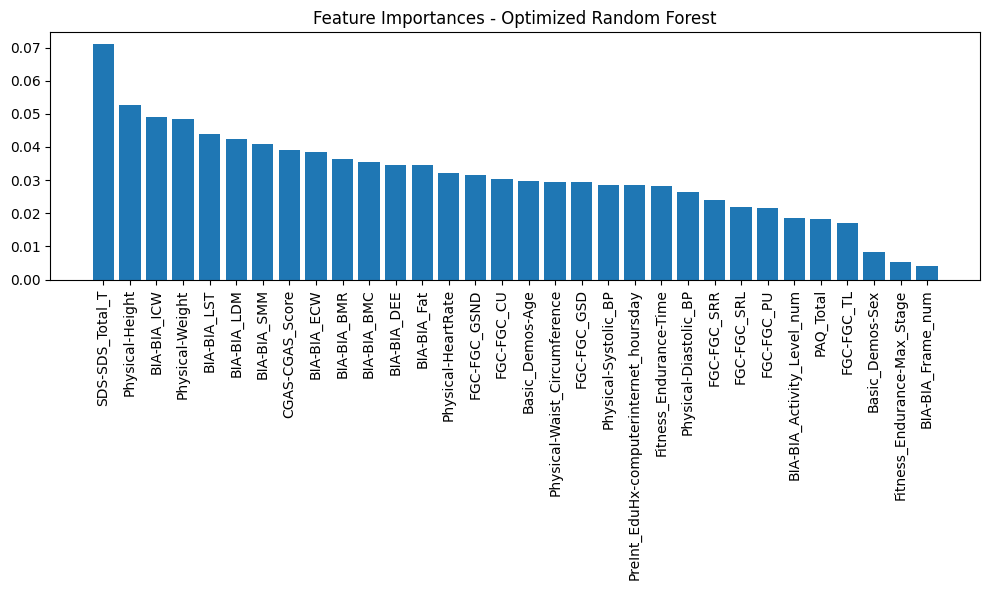

In [17]:
# Feature importance plot
importances = best_rf.feature_importances_
feature_names = X.columns
sorted_indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[sorted_indices], align='center')
plt.xticks(range(len(importances)), feature_names[sorted_indices], rotation=90)
plt.title("Feature Importances - Optimized Random Forest")
plt.tight_layout()
plt.show()

Permutation importance

Permutation importance è un metodo più robusto per valutare l'importanza delle feature, in quanto misura l'impatto sulla performance del modello quando i valori di una feature vengono casualmente shufflati, rompendo così la relazione tra quella feature e il target. Questo metodo è particolarmente utile per modelli complessi come le random forest, dove l'importanza basata sui criteri di divisione può essere fuorviante a causa di correlazioni tra le feature o di bias verso feature con più livelli.

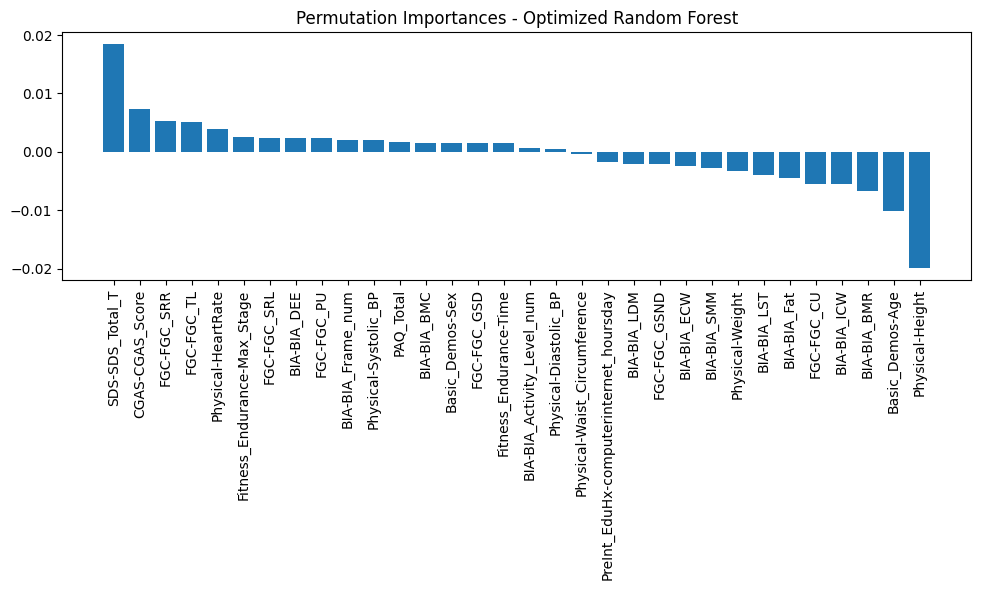

In [18]:
# permutation importance

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(best_rf, X_test, y_test, n_repeats=10, random_state=42)
perm_sorted_indices = np.argsort(perm_importance.importances_mean)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(perm_importance.importances_mean)), perm_importance.importances_mean[
    perm_sorted_indices], align='center')
plt.xticks(range(len(perm_importance.importances_mean)), feature_names[perm_sorted_indices], rotation=90)
plt.title("Permutation Importances - Optimized Random Forest") 
plt.tight_layout()
plt.show()


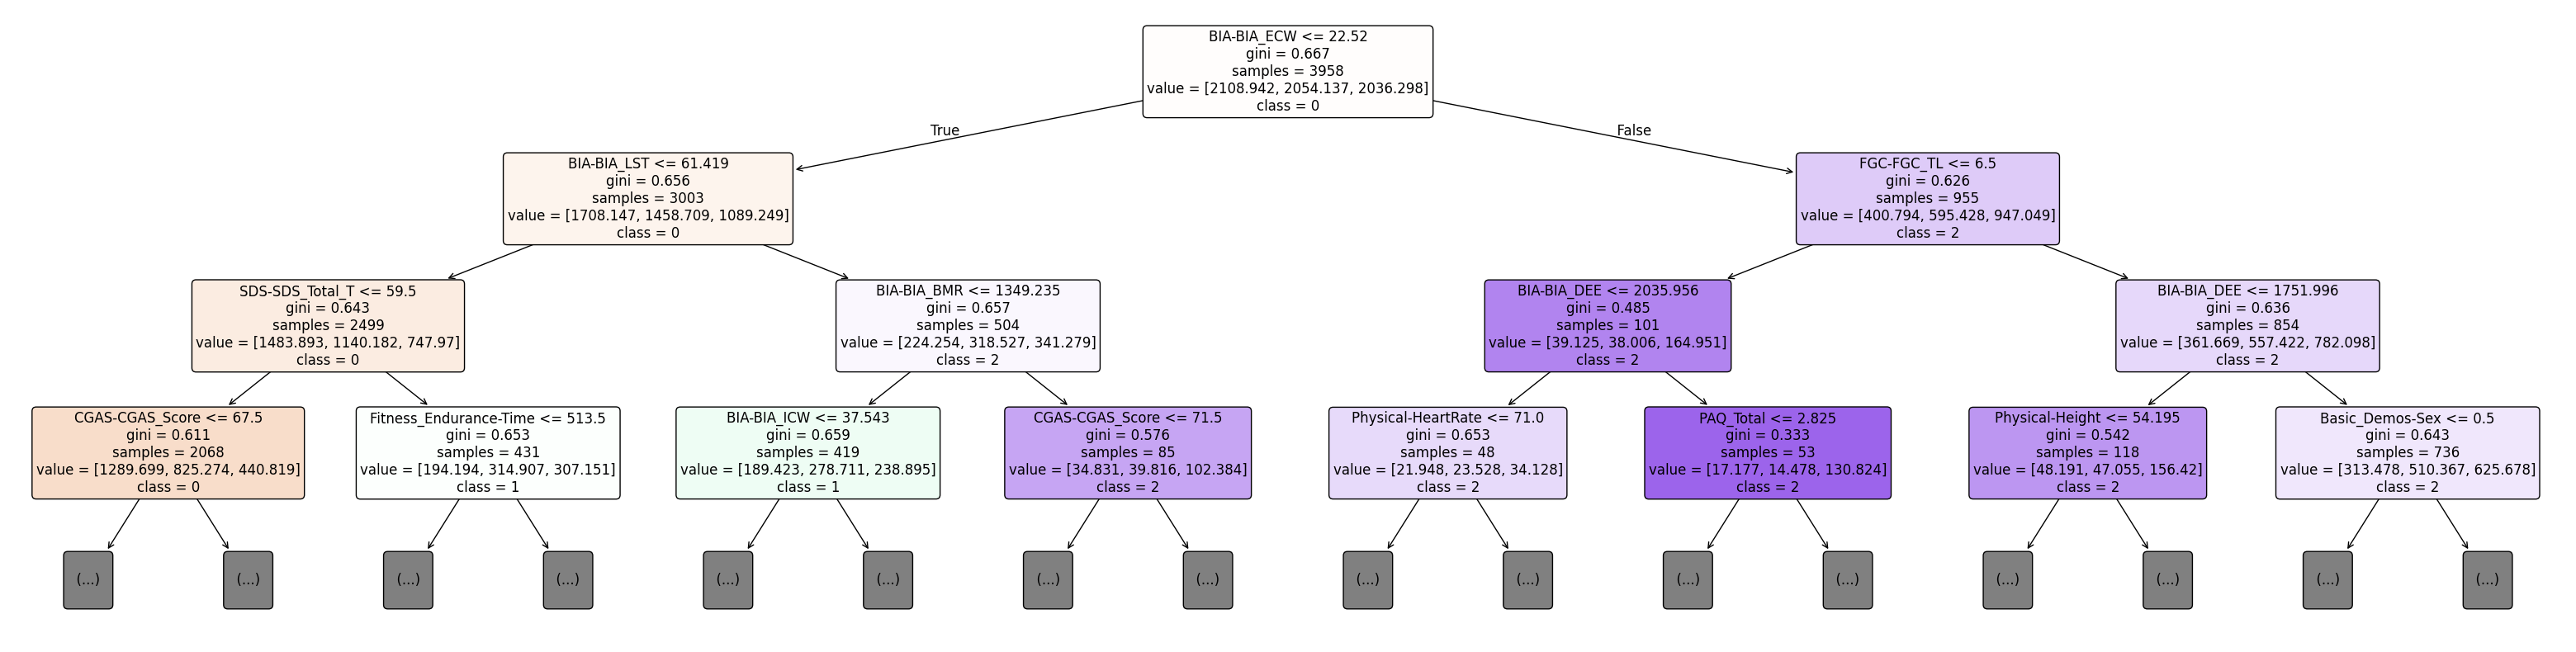

In [21]:
# plot the first tree 
from sklearn.tree import plot_tree
plt.figure(figsize=(40, 10))
# best_rf.estimators_[0] corresponds to the first tree in the forest
plot_tree(best_rf.estimators_[0], filled=True, feature_names=X.columns, class_names=['0', '1', '2', '3'], max_depth=3, fontsize=12, rounded=True)  # Limitiamo la profondità per una visualizzazione chiara
#plt.title("Visualization of One Tree from the Optimized Random Forest")
plt.show()

## 2. **ExtraTreesClassifier**

4 classes, imbalanced

Starting Extra Trees Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}
Best Balanced Accuracy Score (CV): 0.3759

Evaluating Best Extra Trees Model on Test Set...


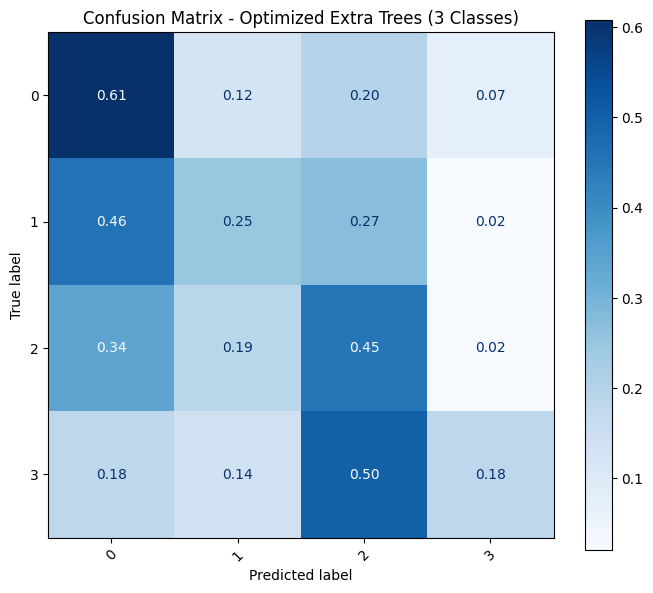

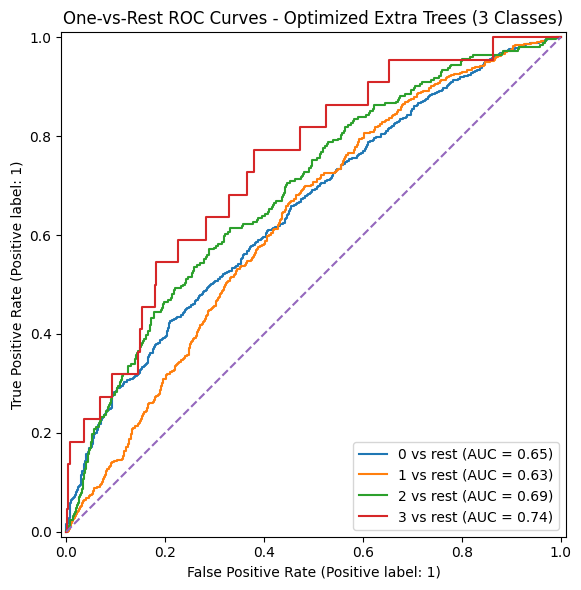

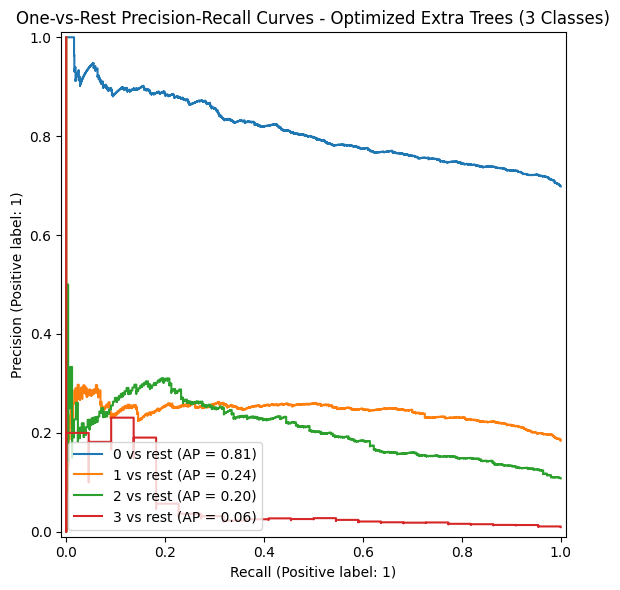


Classification report - Optimized Extra Trees (3 Classes)


,precision,recall,f1-score,support
0,0.776224,0.608034,0.681911,1643.000000
1,0.296703,0.249423,0.271016,433.000000
2,0.202128,0.448819,0.278729,254.000000
3,0.029197,0.181818,0.050314,22.000000
accuracy,0.520833,0.520833,0.520833,0.520833
macro avg,0.326063,0.372023,0.320493,2352.000000
weighted avg,0.618959,0.520833,0.556817,2352.000000


In [27]:
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist_et = {
    # Numero di alberi decisionali estremamente casuali
    'n_estimators': [100, 200, 300, 500],
    
    # Massima profondità degli alberi
    'max_depth': [None, 10, 20, 30, 40],
    
    # Numero minimo di campioni per dividere un nodo
    'min_samples_split': [2, 5, 10],

    # Funzione di impurità per la divisione dei nodi
    'criterion': ['gini', 'entropy'],
    
    # Numero minimo di campioni in una foglia
    'min_samples_leaf': [1, 2, 4],
    
    # Strategia di selezione delle feature ad ogni split
    'max_features': ['sqrt', 'log2', None],
    
    # Bilanciamento dinamico basato sulla distribuzione bootstrap dei dati
    'class_weight': ['balanced', 'balanced_subsample']
}

# Modello base Extra Trees
et_base = ExtraTreesClassifier(random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Extra Trees Hyperparameter Tuning...")

random_search_et = RandomizedSearchCV(
    estimator=et_base,
    param_distributions=param_dist_et,
    n_iter=50,                     # 50 combinazioni casuali nello spazio dei parametri
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulle classi minoritarie
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi (senza alterazioni esterne)
random_search_et.fit(X_train, y_train)

# Estrazione del modello migliore
best_et = random_search_et.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_et.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_et.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Extra Trees Model on Test Set...")

# Lanciamo la valutazione passando direttamente l'estimatore ottimizzato
results, report_df = evaluate_classifier(
    model=best_et,
    X_test=X_test,       # Test set reale a 3 classi
    y_test=y_test,
    model_name="Optimized Extra Trees (3 Classes)",
    normalize_cm="true"
)

3 classes, imbalanced

In [ ]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================================
# 0. AGGREGAZIONE CLASSI E NUOVO SPLIT (Da eseguire prima del tuo codice)
# =========================================================================

# Se nel tuo array/dataframe i tag partono da 0 (0, 1, 2, 3), la classe 3 è il valore 2 e la 4 è il valore 3.
# Con replace({3: 2}) uniamo la classe più grave alla precedente.
y_clean_3classes = df['sii'].replace({3: 2})

print("Nuova distribuzione delle 3 macro-classi:")
print(Counter(y_clean_3classes))
# Risultato atteso: {0: 5476, 1: 1444, 2: 919}

# Rigeneriamo i dataset di Train e Test stratificati sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.2, random_state=42, stratify=y_clean_3classes
)

print(f"\nData preparation completata. Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Puoi lanciare la tua RandomizedSearch")

Nuova distribuzione delle 3 macro-classi:
Counter({0: 5476, 1: 1444, 2: 919})

Data preparation completata. Train size: (6271, 32), Test size: (1568, 32)
Puoi lanciare la tua RandomizedSearch della Random Forest...


Starting Extra Trees Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'entropy', 'class_weight': 'balanced'}
Best Balanced Accuracy Score (CV): 0.4775

Evaluating Best Extra Trees Model on Test Set...


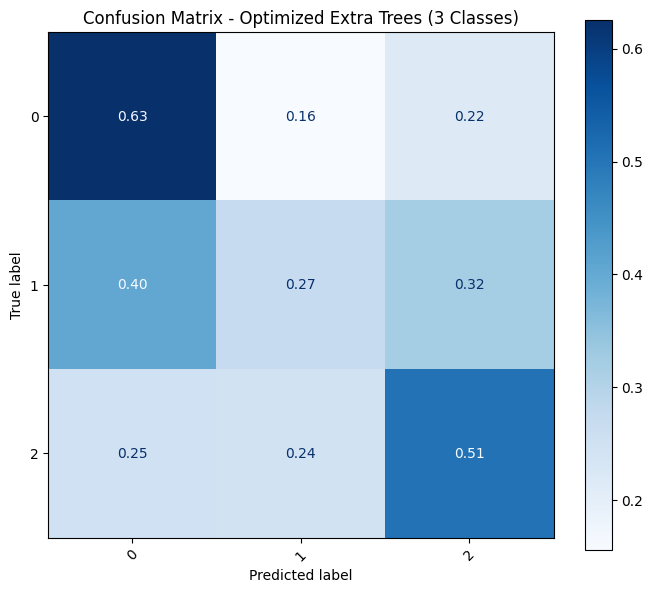

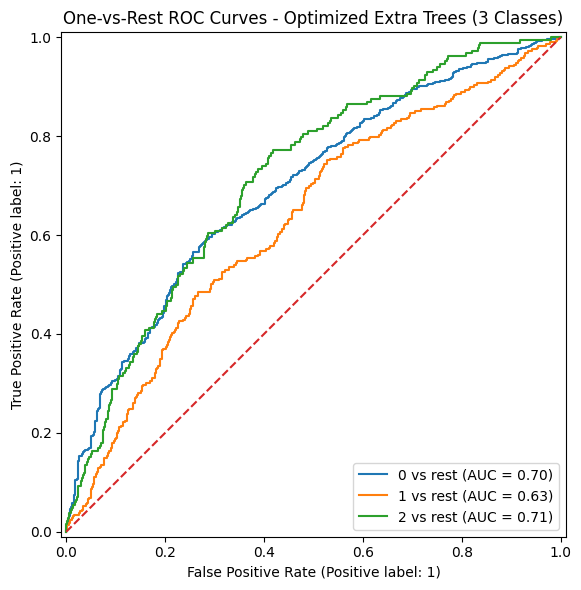

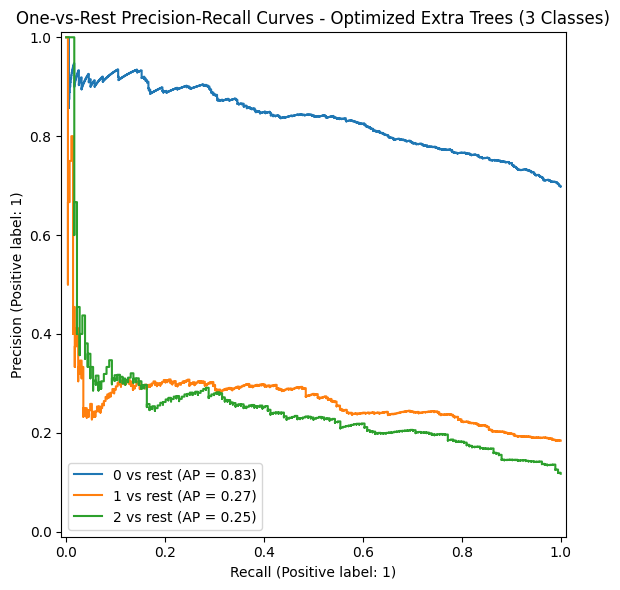


Classification report - Optimized Extra Trees (3 Classes)


,precision,recall,f1-score,support
0,0.807783,0.625571,0.705095,1095.000000
1,0.267797,0.273356,0.270548,289.000000
2,0.218824,0.505435,0.305419,184.000000
accuracy,0.546556,0.546556,0.546556,0.546556
macro avg,0.431468,0.468121,0.427021,1568.000000
weighted avg,0.639145,0.546556,0.578102,1568.000000


In [29]:
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
param_dist_et = {
    # Numero di alberi decisionali estremamente casuali
    'n_estimators': [100, 200, 300, 500],
    
    # Massima profondità degli alberi
    'max_depth': [None, 10, 20, 30, 40],
    
    # Numero minimo di campioni per dividere un nodo
    'min_samples_split': [2, 5, 10],

    # Funzione di impurità per la divisione dei nodi
    'criterion': ['gini', 'entropy'],
    
    # Numero minimo di campioni in una foglia
    'min_samples_leaf': [1, 2, 4],
    
    # Strategia di selezione delle feature ad ogni split
    'max_features': ['sqrt', 'log2', None],
    
    # Bilanciamento dinamico basato sulla distribuzione bootstrap dei dati
    'class_weight': ['balanced', 'balanced_subsample']
}

# Modello base Extra Trees
et_base = ExtraTreesClassifier(random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Extra Trees Hyperparameter Tuning...")

random_search_et = RandomizedSearchCV(
    estimator=et_base,
    param_distributions=param_dist_et,
    n_iter=50,                     # 50 combinazioni casuali nello spazio dei parametri
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulle classi minoritarie
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi (senza alterazioni esterne)
random_search_et.fit(X_train, y_train)

# Estrazione del modello migliore
best_et = random_search_et.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_et.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_et.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Extra Trees Model on Test Set...")

# Lanciamo la valutazione passando direttamente l'estimatore ottimizzato
results, report_df = evaluate_classifier(
    model=best_et,
    X_test=X_test,       # Test set reale a 3 classi
    y_test=y_test,
    model_name="Optimized Extra Trees (3 Classes)",
    normalize_cm="true"
)

## 3. **Bagging**

4 classes, imblanced

Starting Bagging + Decision Tree Hyperparameter Tuning...
This setup will run exponentially faster than SVC.
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 200, 'max_samples': 0.9, 'max_features': 1.0, 'estimator__min_samples_split': 5, 'estimator__min_samples_leaf': 4, 'estimator__max_depth': 10, 'estimator__criterion': 'gini'}
Best Balanced Accuracy Score (CV): 0.3402

Evaluating Best Bagging + Decision Tree Model on Test Set...


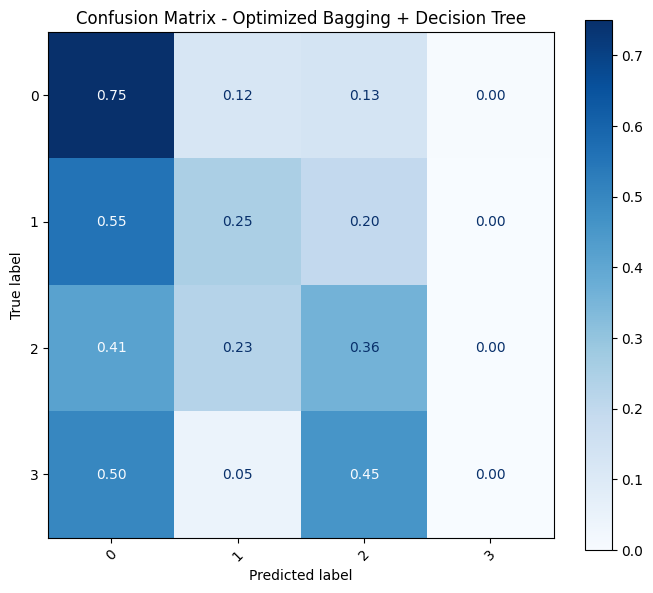

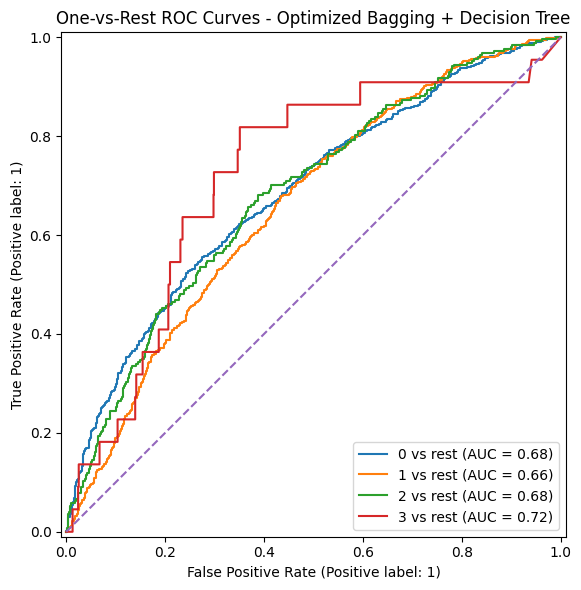

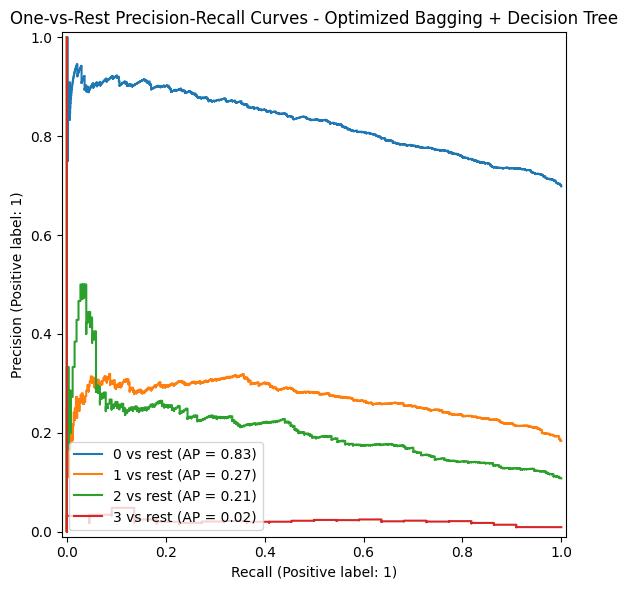


Classification report - Optimized Bagging + Decision Tree


,precision,recall,f1-score,support
0,0.775960,0.750456,0.762995,1643.000000
1,0.300000,0.249423,0.272383,433.000000
2,0.228643,0.358268,0.279141,254.000000
3,0.000000,0.000000,0.000000,22.000000
accuracy,0.608844,0.608844,0.608844,0.608844
macro avg,0.326151,0.339537,0.328630,2352.000000
weighted avg,0.621972,0.608844,0.613284,2352.000000


In [36]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
# Usiamo il prefisso 'estimator__' per configurare l'albero di base
param_dist_bagging_dt = {
    # Parametri del Bagging
    'n_estimators': [50, 100, 200, 300],       # Ora possiamo permetterci centinaia di alberi!
    'max_samples': [0.5, 0.7, 0.9, 1.0],       # Quanti campioni clonare per albero
    'max_features': [0.5, 0.7, 0.9, 1.0],      # Quante feature dare a ogni albero
    
    # Parametri del Decision Tree sottostante
    'estimator__max_depth': [None, 10, 20, 30, 40],
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}

# Configuriamp il Decision Tree di base con la gestione dello sbilanciamento
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo il BaggingClassifier inserendo l'albero appena creato
bagging_dt_model = BaggingClassifier(estimator=dt_base, random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Bagging + Decision Tree Hyperparameter Tuning...")
print("This setup will run exponentially faster than SVC.")

random_search_bag_dt = RandomizedSearchCV(
    estimator=bagging_dt_model,
    param_distributions=param_dist_bagging_dt,
    n_iter=40,                     # Esploriamo 40 combinazioni (molto più approfondito)
    cv=5,                          # 5-Fold Cross-Validation stratificata sulle 3 classi
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla classe minoritaria
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi sbilanciati
random_search_bag_dt.fit(X_train, y_train)

# Estrazione del modello migliore
best_bagging_dt = random_search_bag_dt.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_bag_dt.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_bag_dt.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Bagging + Decision Tree Model on Test Set...")

# Inviamo il modello finale alla tua funzione per generare metriche e grafici
results, report_df = evaluate_classifier(
    model=best_bagging_dt,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi
    y_test=y_test,
    model_name="Optimized Bagging + Decision Tree",
    normalize_cm="true"
)

3 classes, imbalanced

In [38]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================================
# 0. AGGREGAZIONE CLASSI E NUOVO SPLIT (Da eseguire prima del tuo codice)
# =========================================================================

# Se nel tuo array/dataframe i tag partono da 0 (0, 1, 2, 3), la classe 3 è il valore 2 e la 4 è il valore 3.
# Con replace({3: 2}) uniamo la classe più grave alla precedente.
y_clean_3classes = df['sii'].replace({3: 2})

print("Nuova distribuzione delle 3 macro-classi:")
print(Counter(y_clean_3classes))
# Risultato atteso: {0: 5476, 1: 1444, 2: 919}

# Rigeneriamo i dataset di Train e Test stratificati sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.2, random_state=42, stratify=y_clean_3classes
)

print(f"\nData preparation completata. Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Puoi lanciare la tua RandomizedSearch")

Nuova distribuzione delle 3 macro-classi:
Counter({0: 5476, 1: 1444, 2: 919})

Data preparation completata. Train size: (6271, 32), Test size: (1568, 32)
Puoi lanciare la tua RandomizedSearch


Starting Bagging + Decision Tree Hyperparameter Tuning...
This setup will run exponentially faster than SVC.
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 200, 'max_samples': 0.9, 'max_features': 1.0, 'estimator__min_samples_split': 5, 'estimator__min_samples_leaf': 4, 'estimator__max_depth': 10, 'estimator__criterion': 'gini'}
Best Balanced Accuracy Score (CV): 0.4541

Evaluating Best Bagging + Decision Tree Model on Test Set...


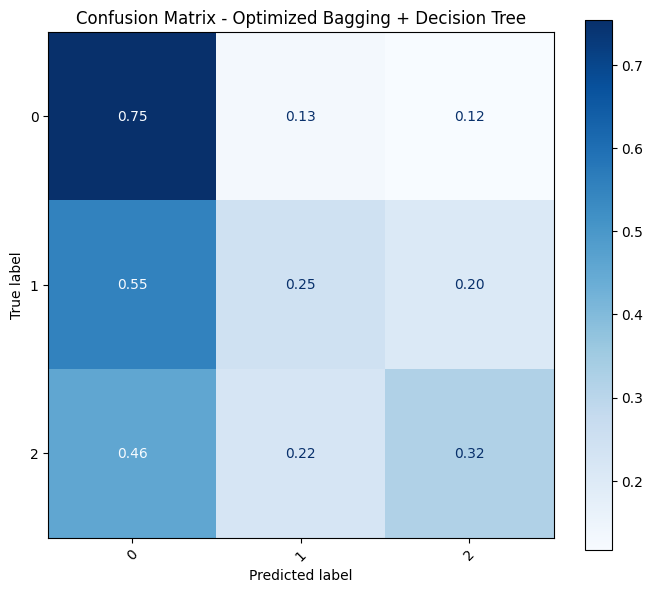

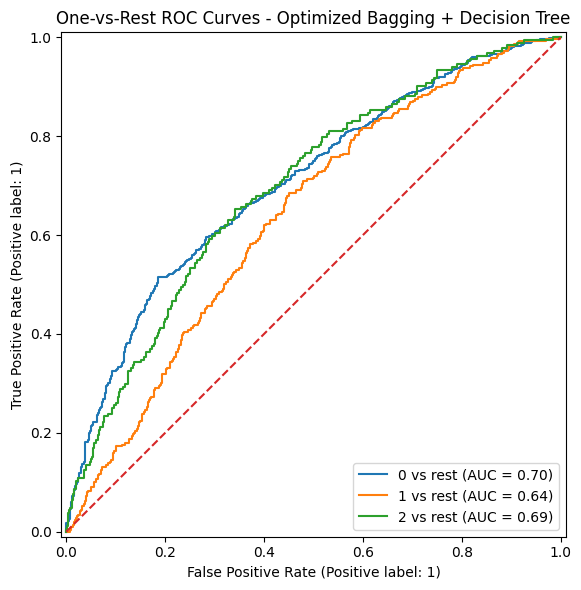

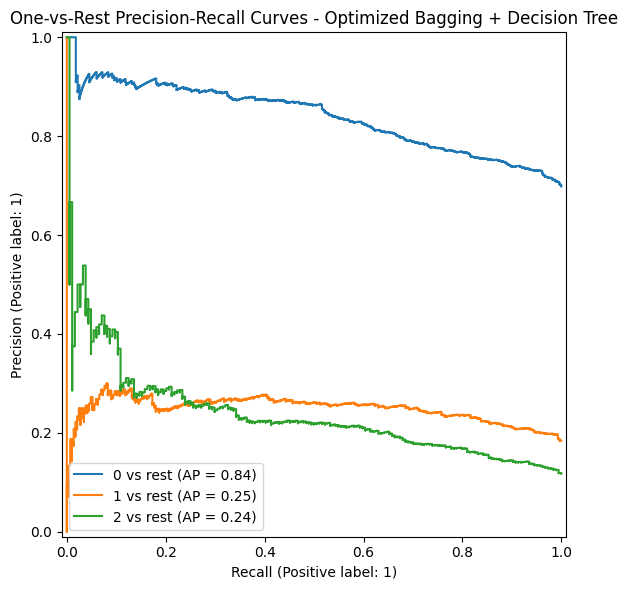


Classification report - Optimized Bagging + Decision Tree


,precision,recall,f1-score,support
0,0.772685,0.754338,0.763401,1095.000000
1,0.280632,0.245675,0.261993,289.000000
2,0.239837,0.320652,0.274419,184.000000
accuracy,0.609694,0.609694,0.609694,0.609694
macro avg,0.431052,0.440222,0.433271,1568.000000
weighted avg,0.619466,0.609694,0.613605,1568.000000


In [39]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
# Usiamo il prefisso 'estimator__' per configurare l'albero di base
param_dist_bagging_dt = {
    # Parametri del Bagging
    'n_estimators': [50, 100, 200, 300],       # Ora possiamo permetterci centinaia di alberi!
    'max_samples': [0.5, 0.7, 0.9, 1.0],       # Quanti campioni clonare per albero
    'max_features': [0.5, 0.7, 0.9, 1.0],      # Quante feature dare a ogni albero
    
    # Parametri del Decision Tree sottostante
    'estimator__max_depth': [None, 10, 20, 30, 40],
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4]
}

# Configuriamp il Decision Tree di base con la gestione dello sbilanciamento
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo il BaggingClassifier inserendo l'albero appena creato
bagging_dt_model = BaggingClassifier(estimator=dt_base, random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Bagging + Decision Tree Hyperparameter Tuning...")
print("This setup will run exponentially faster than SVC.")

random_search_bag_dt = RandomizedSearchCV(
    estimator=bagging_dt_model,
    param_distributions=param_dist_bagging_dt,
    n_iter=40,                     # Esploriamo 40 combinazioni (molto più approfondito)
    cv=5,                          # 5-Fold Cross-Validation stratificata sulle 3 classi
    scoring='balanced_accuracy',   # Ottimizzazione focalizzata sulla classe minoritaria
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi sbilanciati
random_search_bag_dt.fit(X_train, y_train)

# Estrazione del modello migliore
best_bagging_dt = random_search_bag_dt.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_bag_dt.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_bag_dt.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Bagging + Decision Tree Model on Test Set...")

# Inviamo il modello finale alla tua funzione per generare metriche e grafici
results, report_df = evaluate_classifier(
    model=best_bagging_dt,
    X_test=X_test,       # Test set reale sbilanciato a 4 classi
    y_test=y_test,
    model_name="Optimized Bagging + Decision Tree",
    normalize_cm="true"
)

## 4. **Boosting (AdaBoost)**

4 classes, imbalanced

Starting AdaBoost + Decision Tree Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 200, 'learning_rate': 0.05, 'estimator__min_samples_split': 5, 'estimator__max_depth': 5, 'estimator__criterion': 'gini'}
Best Balanced Accuracy Score (CV): 0.3626

Evaluating Best AdaBoost Model on Test Set...


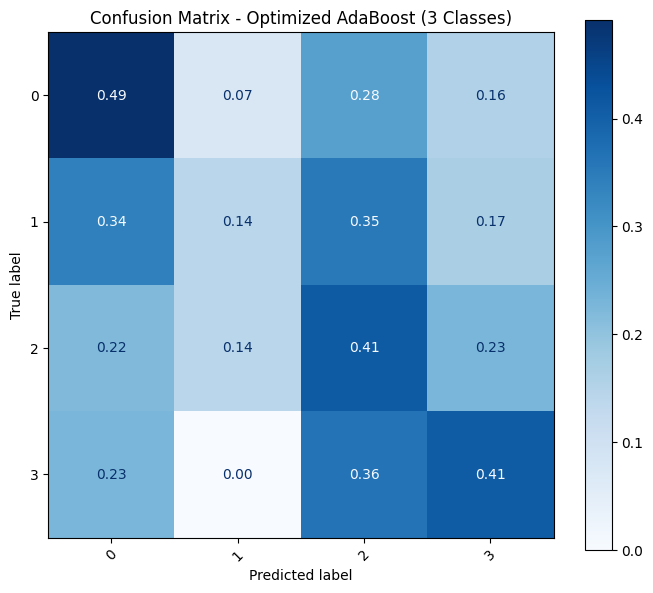

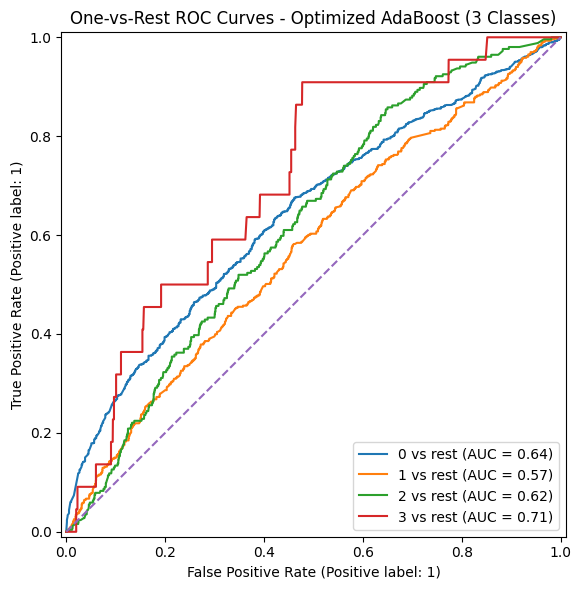

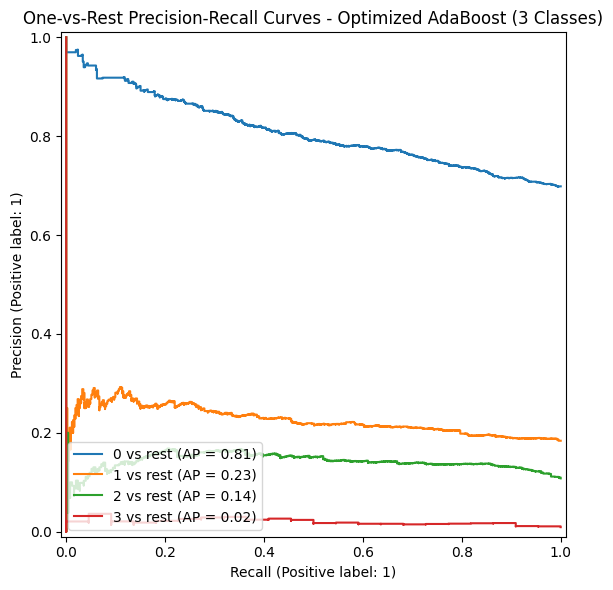


Classification report - Optimized AdaBoost (3 Classes)


,precision,recall,f1-score,support
0,0.795276,0.491783,0.607747,1643.000000
1,0.277273,0.140878,0.186830,433.000000
2,0.144645,0.409449,0.213772,254.000000
3,0.022670,0.409091,0.042959,22.000000
accuracy,0.417517,0.417517,0.417517,0.417517
macro avg,0.309966,0.362800,0.262827,2352.000000
weighted avg,0.622422,0.417517,0.482427,2352.000000


In [37]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
# Usiamo il prefisso 'estimator__' per modificare le proprietà dell'albero base
param_dist_adaboost = {
    # Parametri di AdaBoost
    'n_estimators': [50, 100, 200, 300, 500],   # Numero di round di boosting
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0], # Quanto ogni albero corregge il precedente
    
    # Parametri del Decision Tree di base
    # Nota: AdaBoost storicamente usa alberi poco profondi (es. max_depth tra 1 e 5)
    'estimator__max_depth': [1, 2, 3, 5],        
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__min_samples_split': [2, 5, 10]
}

# Configuriamp il Decision Tree di base con il bilanciamento delle classi
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo l'AdaBoostClassifier passando l'albero come stimatore principale
adaboost_base = AdaBoostClassifier(estimator=dt_base, random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting AdaBoost + Decision Tree Hyperparameter Tuning...")

random_search_ada = RandomizedSearchCV(
    estimator=adaboost_base,
    param_distributions=param_dist_adaboost,
    n_iter=40,                     # 40 combinazioni stocastiche
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Focus sul recupero delle classi minoritarie
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi sbilanciati
random_search_ada.fit(X_train, y_train)

# Estrazione del modello migliore
best_adaboost = random_search_ada.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_ada.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_ada.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best AdaBoost Model on Test Set...")

# Essendo un modello nativo sklearn, passiamo direttamente l'oggetto alla tua funzione
results, report_df = evaluate_classifier(
    model=best_adaboost,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi
    y_test=y_test,
    model_name="Optimized AdaBoost (3 Classes)",
    normalize_cm="true"
)

3 classes, imbalanced

In [ ]:
from collections import Counter
from sklearn.model_selection import train_test_split

# =========================================================================
# 0. AGGREGAZIONE CLASSI E NUOVO SPLIT (Da eseguire prima del tuo codice)
# =========================================================================

# Se nel tuo array/dataframe i tag partono da 0 (0, 1, 2, 3), la classe 3 è il valore 2 e la 4 è il valore 3.
# Con replace({3: 2}) uniamo la classe più grave alla precedente.
y_clean_3classes = df['sii'].replace({3: 2})

print("Nuova distribuzione delle 3 macro-classi:")
print(Counter(y_clean_3classes))
# Risultato atteso: {0: 5476, 1: 1444, 2: 919}

# Rigeneriamo i dataset di Train e Test stratificati sulle 3 nuove classi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.2, random_state=42, stratify=y_clean_3classes
)

print(f"\nData preparation completata. Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Puoi lanciare la tua RandomizedSearch")

Starting AdaBoost + Decision Tree Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'n_estimators': 200, 'learning_rate': 0.1, 'estimator__min_samples_split': 10, 'estimator__max_depth': 3, 'estimator__criterion': 'gini'}
Best Balanced Accuracy Score (CV): 0.4878

Evaluating Best AdaBoost Model on Test Set...


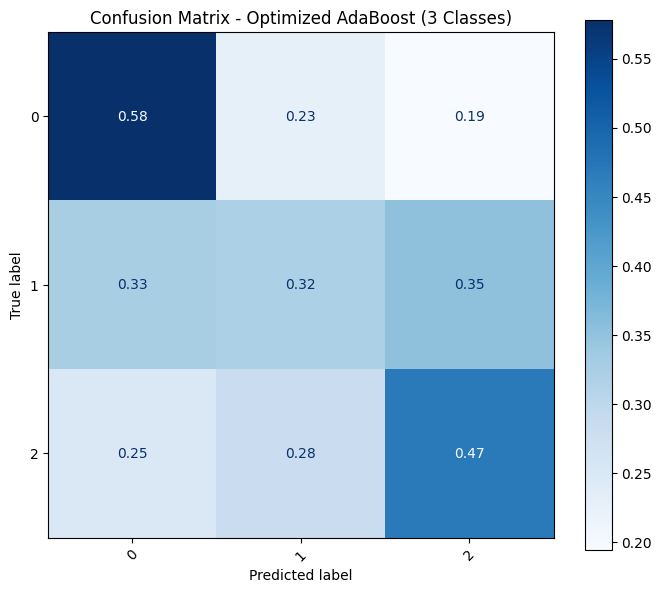

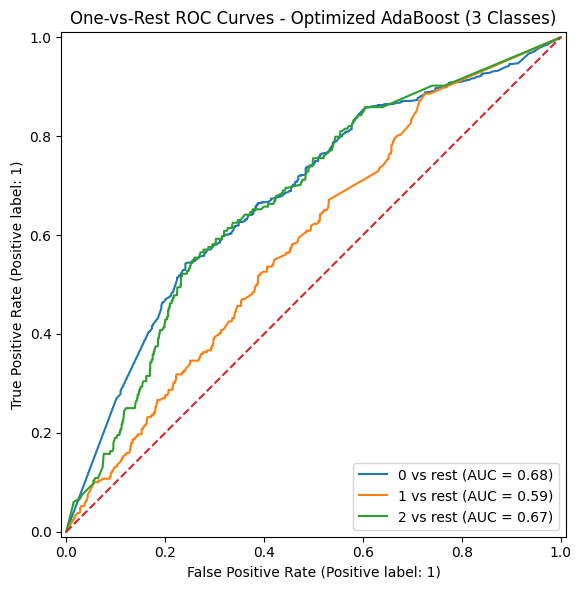

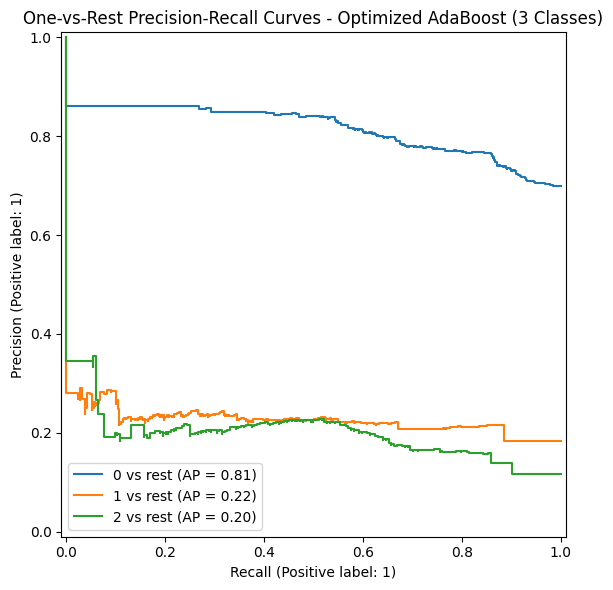


Classification report - Optimized AdaBoost (3 Classes)


,precision,recall,f1-score,support
0,0.818887,0.578082,0.677730,1095.000000
1,0.236041,0.321799,0.272328,289.000000
2,0.214464,0.467391,0.294017,184.000000
accuracy,0.517857,0.517857,0.517857,0.517857
macro avg,0.423131,0.455758,0.414692,1568.000000
weighted avg,0.640535,0.517857,0.557982,1568.000000


In [40]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI
# =========================================================================
# Usiamo il prefisso 'estimator__' per modificare le proprietà dell'albero base
param_dist_adaboost = {
    # Parametri di AdaBoost
    'n_estimators': [50, 100, 200, 300, 500],   # Numero di round di boosting
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0], # Quanto ogni albero corregge il precedente
    
    # Parametri del Decision Tree di base
    # Nota: AdaBoost storicamente usa alberi poco profondi (es. max_depth tra 1 e 5)
    'estimator__max_depth': [1, 2, 3, 5],        
    'estimator__criterion': ['gini', 'entropy'],
    'estimator__min_samples_split': [2, 5, 10]
}

# Configuriamp il Decision Tree di base con il bilanciamento delle classi
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo l'AdaBoostClassifier passando l'albero come stimatore principale
adaboost_base = AdaBoostClassifier(estimator=dt_base, random_state=42)

# =========================================================================
# 2. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting AdaBoost + Decision Tree Hyperparameter Tuning...")

random_search_ada = RandomizedSearchCV(
    estimator=adaboost_base,
    param_distributions=param_dist_adaboost,
    n_iter=40,                     # 40 combinazioni stocastiche
    cv=5,                          # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',   # Focus sul recupero delle classi minoritarie
    n_jobs=-1,                     # Sfrutta tutti i core della CPU
    random_state=42,
    verbose=1
)

# Fit sui dati originali a 3 classi sbilanciati
random_search_ada.fit(X_train, y_train)

# Estrazione del modello migliore
best_adaboost = random_search_ada.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_ada.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_ada.best_score_:.4f}\n")

# =========================================================================
# 3. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best AdaBoost Model on Test Set...")

# Essendo un modello nativo sklearn, passiamo direttamente l'oggetto alla tua funzione
results, report_df = evaluate_classifier(
    model=best_adaboost,
    X_test=X_test,       # Test set reale sbilanciato a 3 classi
    y_test=y_test,
    model_name="Optimized AdaBoost (3 Classes)",
    normalize_cm="true"
)